# COVID-19 Comparative Analysis: Italy vs Pakistan

 **Author:** Abu Bakar

Objective: This project analyzes and compares COVID-19 trends in Italy and Pakistan using the Our World in Data dataset.

# Import libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import requests

## Data Loading and Filtering

We load the dataset and filter only Italy and Pakistan for comparison.

In [13]:
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)

countries = df[df["location"].isin(["Italy", "Pakistan"])].copy()

countries["date"] = pd.to_datetime(countries["date"])
countries = countries.sort_values(["location", "date"])

## Data Cleaning and Feature Engineering

We select relevant columns and create new indicators for analysis.

In [14]:
countries = countries[
    ["location", "date", "total_cases", "total_deaths",
     "new_cases", "people_vaccinated", "population"]
].copy()

countries["total_cases"] = countries["total_cases"].fillna(0)
countries["total_deaths"] = countries["total_deaths"].fillna(0)
countries["new_cases"] = countries["new_cases"].fillna(0)
countries["people_vaccinated"] = countries["people_vaccinated"].fillna(0)

# Features
countries["cases_per_million"] = countries["total_cases"] / countries["population"] * 1e6
countries["death_rate"] = (countries["total_deaths"] / countries["total_cases"]) * 100
countries["death_rate"] = countries["death_rate"].replace([float("inf")], 0).fillna(0)

countries["vaccinated_pct"] = countries["people_vaccinated"] / countries["population"] * 100

# smoothing
countries["cases_smooth"] = countries.groupby("location")["total_cases"].transform(
    lambda x: x.rolling(7).mean()
)

countries["new_cases_smooth"] = countries.groupby("location")["new_cases"].transform(
    lambda x: x.rolling(7).mean()
)

## Total COVID-19 Cases Over Time

Italy shows earlier and faster growth compared to Pakistan. The below graph of total number of cases over time represents that in the first two years Italy's cases increases to 5 millions and after 2022 there is a huge and rapid increase in the total number of cases. In the end of 2024, 25 million cases reported which is approximately half of the population of Italy. On the other hand, we can see the slow and gradual increase in the total number of cases. In the start of 2022, it reaches to 5 million cases and then the curve flattens and cases decreases gradualy with respect to time and in the end of 2024 it reaches to 2 million approximately.

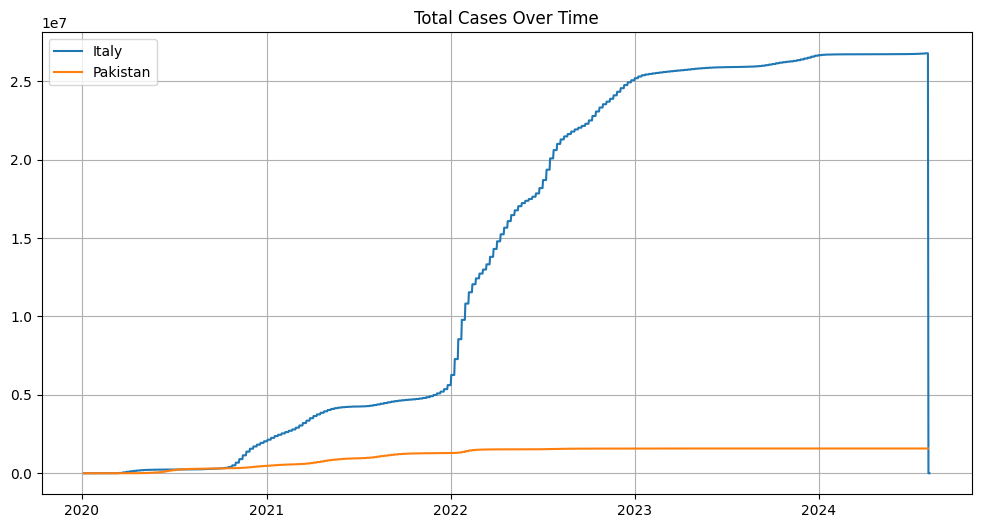

In [15]:
plt.figure(figsize=(12,6))

for c in ["Italy", "Pakistan"]:
    d = countries[countries["location"] == c]
    plt.plot(d["date"], d["total_cases"], label=c)

plt.title("Total Cases Over Time")
plt.legend()
plt.grid()
plt.show()

## Cases per Million

This adjusts for population differences between the two countries. This graph compares the relative infection density between the two Italy and Pakistan by tracking cumulative cases per million people from 2020 to mid-2024. Italy shows a severe impact per capita, climbing steeply throughout 2022 to peak at over 450,000 cases per million, which implies roughly 45% of its population tested positive. By contrast, Pakistan remains virtually flat along the bottom baseline, highlighting a drastically lower per-capita infection or recorded testing rate.


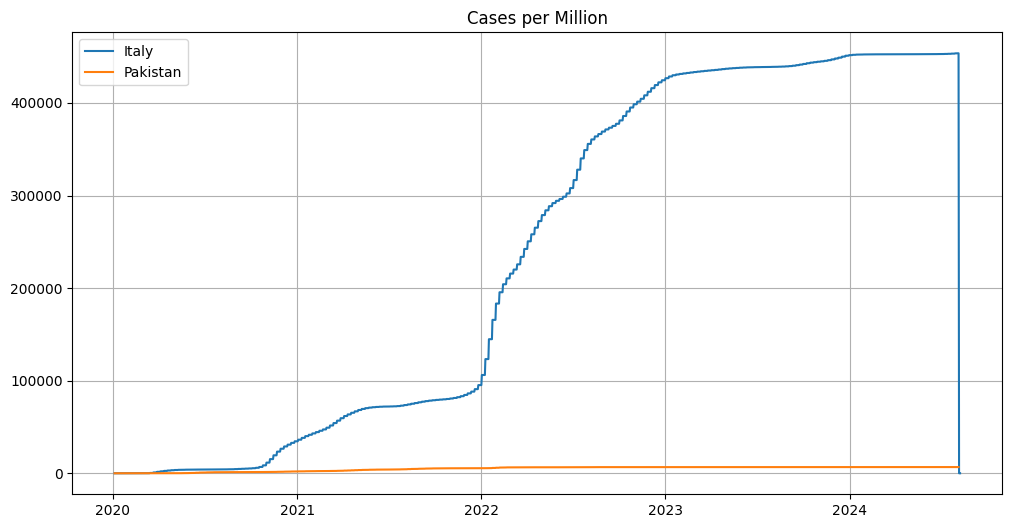

In [16]:
plt.figure(figsize=(12,6))

for c in ["Italy", "Pakistan"]:
    d = countries[countries["location"] == c]
    plt.plot(d["date"], d["cases_per_million"], label=c)

plt.title("Cases per Million")
plt.legend()
plt.grid()
plt.show()

## Death Rate

Shows percentage of confirmed cases that resulted in death. This graph tracks the recorded death rate percentage for both countries from 2020 through mid-2024. Italy experienced a massive initial spike in early 2020, peaking at over 14% before dropping sharply and eventually stabilizing below 1% from 2022 onward as testing expanded and treatments improved. Conversely, Pakistan saw a much smaller initial rise and maintained a highly stable, consistent death rate of around 2% for the remainder of the timeline.

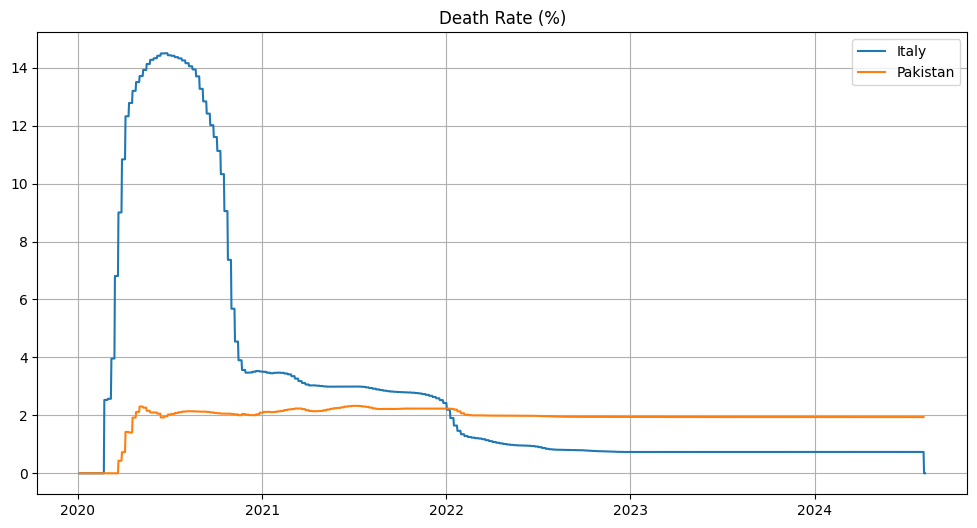

In [17]:
plt.figure(figsize=(12,6))

for c in ["Italy", "Pakistan"]:
    d = countries[countries["location"] == c]
    plt.plot(d["date"], d["death_rate"], label=c)

plt.title("Death Rate (%)")
plt.legend()
plt.grid()
plt.show()

## Vaccination Progress

Italy shows faster vaccination rollout compared to Pakistan. This graph illustrates the percentage of vaccination progress for Italy and Pakistan between 2020 and mid-2024. Italy shows a rapid, smooth upward trajectory starting in early 2021, eventually plateauing at a high vaccination rate of over 85% by mid-2022. Pakistan reflects a slower, more gradual rollout that peaked around 70%, with the erratic, jagged lines toward the end indicating fragmented data reporting or intermittent tracking updates.

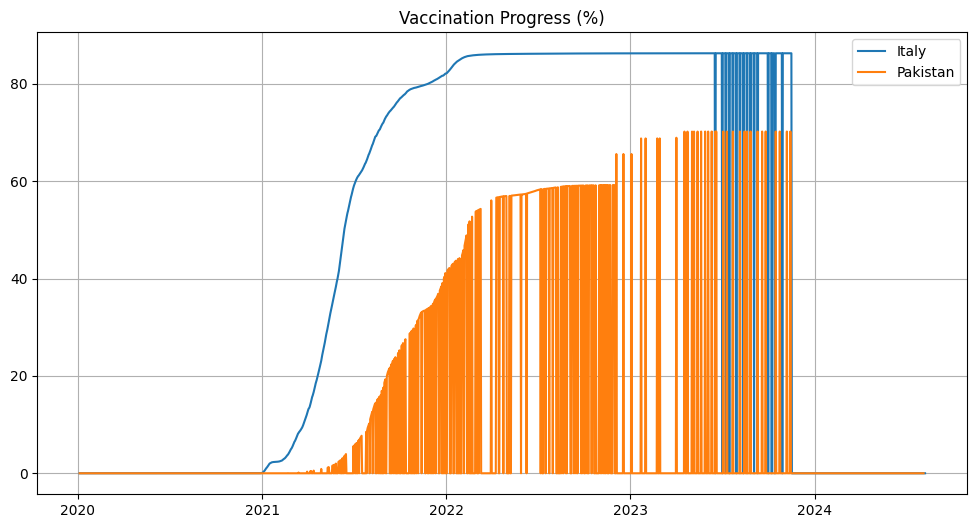

In [18]:
plt.figure(figsize=(12,6))

for c in ["Italy", "Pakistan"]:
    d = countries[countries["location"] == c]
    plt.plot(d["date"], d["vaccinated_pct"], label=c)

plt.title("Vaccination Progress (%)")
plt.legend()
plt.grid()
plt.show()

## Epidemic Waves

7-day smoothing highlights multiple waves of infection. This graph displays the daily COVID-19 cases using a 7-day rolling average to highlight distinct infection waves between 2020 and mid-2024. Italy shows multiple prominent waves, dominated by a massive, sharp peak in early 2022 that surpassed 175,000 daily cases, followed by several smaller but significant surges later that year. Pakistan displays a much lower profile throughout the timeline, with small, rolling waves that peaked well below 10,000 daily cases before flattening out completely after 2022.

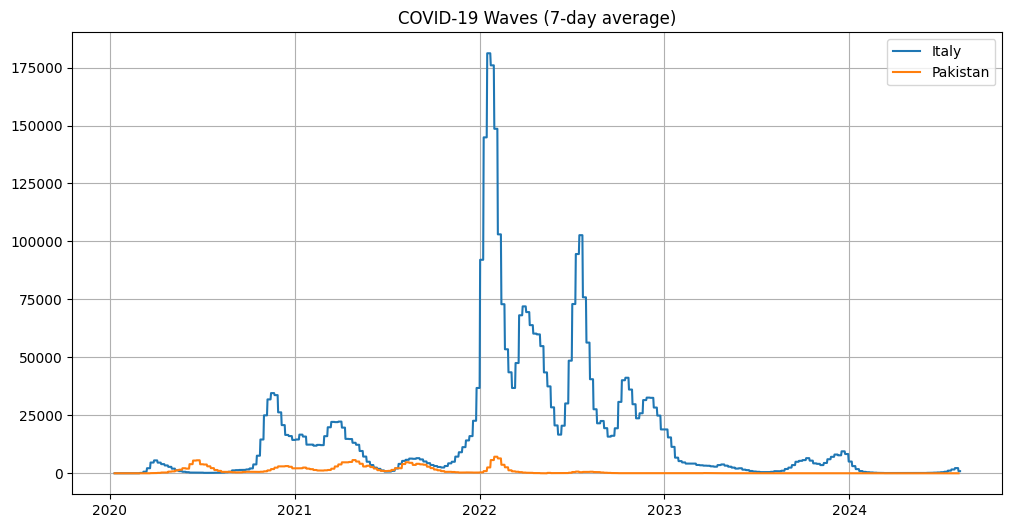

In [19]:
plt.figure(figsize=(12,6))

for c in ["Italy", "Pakistan"]:
    d = countries[countries["location"] == c]
    plt.plot(d["date"], d["new_cases_smooth"], label=c)

plt.title("COVID-19 Waves (7-day average)")
plt.legend()
plt.grid()
plt.show()

## Conclusion

Italy experienced a significantly higher volume and density of infections but successfully reduced its long-term mortality rate through rapid vaccination, whereas Pakistan maintained a lower, flatter case trajectory with a highly stable death rate.

Key findings:

- Infection Density: Italy infected roughly 45% of its population. Pakistan stayed near zero per capita.

- Wave Volatility: Italy suffered explosive surges peaking over 175,000 daily cases. Pakistan kept daily peaks under 10,000.

- Mortality Trends: Italy dropped its initial 14% death rate below 1%. Pakistan maintained a steady 2% rate.

- Vaccination Speed: Italy reached 85% coverage by mid-2022. Pakistan peaked gradually around 70%.

- Data Logging: Both countries suffered severe reporting gaps and zero-drop or unreported data by 2023.